# Character-Level Language Models: Comparing RNN, LSTM, and GRU on Web Text

## Project Overview

This project trains three recurrent architectures as character-level language models on English web text, under identical conditions:

- a vanilla RNN
- a Long Short-Term Memory network (LSTM)
- a Gated Recurrent Unit network (GRU)

All three models use the same data, hidden size, optimizer, and training budget. They are compared on held-out **bits per character (BPC)**, training speed, and the quality of the text they generate. Count-based character n-gram models provide baselines. The error analysis looks at which kinds of characters each model finds hard to predict, and how well each one uses longer context.

**Tools:** Python, PyTorch (CUDA), Hugging Face `datasets` (streaming), NumPy, pandas, matplotlib, seaborn.

## Objective

Measure, rather than assume, how gating (LSTM, GRU) changes the quality and efficiency of a character-level language model compared with a vanilla RNN.

## Dataset

| Property | Value |
|---|---|
| Name | OpenWebText ([`Skylion007/openwebtext`](https://huggingface.co/datasets/Skylion007/openwebtext)) |
| Description | An open recreation of the WebText corpus: web pages linked from Reddit posts with at least three upvotes |
| Sample used | 5,000 documents, drawn with a seeded shuffle from a streamed copy of the dataset |
| License | Released under CC0 by its creators. The underlying web pages remain under their original authors' copyright. |

The notebook **streams** the sample, so it does not need the full multi-gigabyte download. An internet connection is required on first run.

## Setup and Imports

In [ ]:
import math
import re
import time
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from datasets import disable_progress_bars, load_dataset
from huggingface_hub.utils import logging as hf_logging

RANDOM_SEED = 42
N_DOCUMENTS = 5_000
SEQ_LEN = 256
BATCH_SIZE = 128
HIDDEN_SIZE = 512
N_LAYERS = 2
LEARNING_RATE = 2e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_STEPS = 4_000 if device.type == "cuda" else 400   # reduced budget on CPU
EVAL_EVERY = 250

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
MODEL_COLORS = {"RNN": "#eb6834", "LSTM": "#2a78d6", "GRU": "#1baf7a"}
disable_progress_bars()
hf_logging.set_verbosity_error()

print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Device: cuda (NVIDIA GeForce RTX 3060 Ti)


## Data Preparation

The text is kept close to its raw form, because a language model has to learn spelling, capitalization, and punctuation. Stemming or stop-word removal would make the generated text unreadable. Three light normalization steps are applied:

1. Convert curly quotes and dashes to their ASCII equivalents.
2. Drop the remaining non-ASCII characters, which keeps the vocabulary to about 100 symbols.
3. Collapse runs of spaces and blank lines.

The documents are split **by document** (90% / 5% / 5%), so no text from a validation or test document is seen during training.

In [ ]:
ASCII_REPLACEMENTS = {"\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"',
                      "\u2013": "-", "\u2014": "-", "\u2026": "...", "\u00a0": " "}


def normalize_document(text):
    for original, replacement in ASCII_REPLACEMENTS.items():
        text = text.replace(original, replacement)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^\x20-\x7e\n]", "", text)        # printable ASCII and newlines only
    text = re.sub(r"[ \t]+", " ", text)
    return re.sub(r"\n\s*\n+", "\n\n", text).strip()


stream = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
stream = stream.shuffle(seed=RANDOM_SEED, buffer_size=20_000)
documents = [normalize_document(row["text"]) for row in stream.take(N_DOCUMENTS)]
documents = [doc for doc in documents if len(doc) > 200]

rng = np.random.default_rng(RANDOM_SEED)
order = rng.permutation(len(documents))
n_val = n_test = len(documents) // 20
split_documents = {
    "test": [documents[i] for i in order[:n_test]],
    "validation": [documents[i] for i in order[n_test:n_test + n_val]],
    "train": [documents[i] for i in order[n_test + n_val:]],
}
split_text = {name: "\n\n".join(docs) for name, docs in split_documents.items()}

characters = sorted(set(split_text["train"]))
char_to_id = {ch: i for i, ch in enumerate(characters)}
id_to_char = np.array(characters)
VOCAB_SIZE = len(characters)


def encode(text):
    # Characters unseen in training (very rare after ASCII filtering) map to a space
    fallback = char_to_id[" "]
    return np.array([char_to_id.get(ch, fallback) for ch in text], dtype=np.int64)


split_ids = {name: encode(text) for name, text in split_text.items()}
pd.DataFrame({
    "Documents": {name: len(docs) for name, docs in split_documents.items()},
    "Characters": {name: len(ids) for name, ids in split_ids.items()},
}).loc[["train", "validation", "test"]].style.format("{:,}")

,Documents,Characters
train,"4,500","22,152,689"
validation,250,"1,127,740"
test,250,"1,129,128"


In [ ]:
print(f"Vocabulary: {VOCAB_SIZE} characters")
print(repr("".join(characters)))
print("\nSample of training text:\n")
print(split_text["train"][:600])

Vocabulary: 96 characters
'\n !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'

Sample of training text:

UNITED NATIONS (AP) - New U.S. Ambassador Nikki Haley has arrived at the United Nations, announcing a new way the U.S. does business: She says the Trump administration's goal is to show U.S. strength and force and defend its allies - and as for countries opposing America, "We're taking names."

The former South Carolina governor says the United States will "respond accordingly" to opponents.

Haley spoke to the media immediately after entering U.N. headquarters for the first time Friday. She presented her credentials to Secretary-General Antonio Guterres.

She said it's a time for "fresh eyes"


## Exploratory Analysis

A model that ignored context and predicted every character from its overall frequency would score the **unigram entropy** of the text. That is the first baseline any useful model must beat.

Unigram entropy of training text: 4.619 bits per character


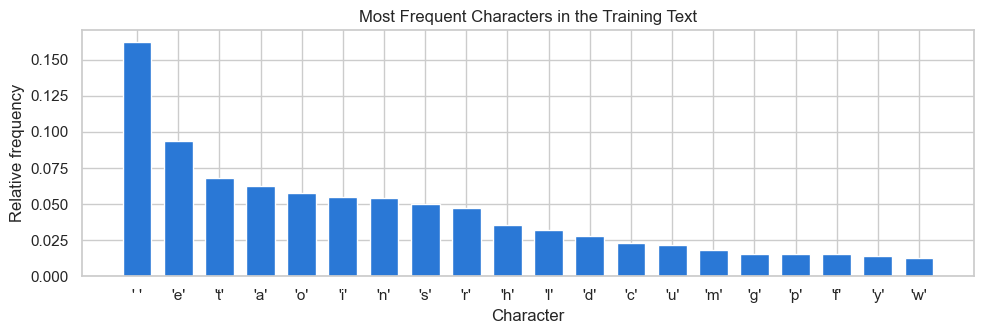

In [ ]:
char_counts = np.bincount(split_ids["train"], minlength=VOCAB_SIZE)
char_probs = char_counts / char_counts.sum()
unigram_entropy = -(char_probs[char_probs > 0] * np.log2(char_probs[char_probs > 0])).sum()
print(f"Unigram entropy of training text: {unigram_entropy:.3f} bits per character")

top_chars = pd.Series(char_probs, index=[repr(c) for c in characters]).nlargest(20)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(top_chars.index, top_chars.values, color="#2a78d6", width=0.7)
ax.set_title("Most Frequent Characters in the Training Text")
ax.set_xlabel("Character")
ax.set_ylabel("Relative frequency")
plt.tight_layout()
plt.show()

## Model Development

### Baselines: character n-gram models

Count-based n-gram models predict each character from the previous *n − 1* characters. Add-*k* smoothing gives unseen combinations a small probability, and *k* is selected on the validation set. To keep counting fast, each n-gram is encoded as a single integer.

In [ ]:
def ngram_codes(ids, n):
    """Encode every length-n window of ids as one integer (base VOCAB_SIZE)."""
    codes = np.zeros(len(ids) - n + 1, dtype=np.int64)
    for offset in range(n):
        codes = codes * VOCAB_SIZE + ids[offset:len(ids) - n + 1 + offset]
    return codes


class CharNgramModel:
    def __init__(self, n, k=1.0):
        self.n, self.k = n, k

    def fit(self, ids):
        self.ngram_keys, self.ngram_counts = np.unique(ngram_codes(ids, self.n), return_counts=True)
        if self.n > 1:
            self.context_keys, self.context_counts = np.unique(ngram_codes(ids[:-1], self.n - 1), return_counts=True)
        return self

    @staticmethod
    def _lookup(keys, counts, queries):
        positions = np.searchsorted(keys, queries).clip(max=len(keys) - 1)
        return np.where(keys[positions] == queries, counts[positions], 0)

    def bits_per_char(self, ids):
        ngram_count = self._lookup(self.ngram_keys, self.ngram_counts, ngram_codes(ids, self.n))
        if self.n > 1:
            context_count = self._lookup(self.context_keys, self.context_counts, ngram_codes(ids[:-1], self.n - 1))
        else:
            context_count = self.ngram_counts.sum()
        probability = (ngram_count + self.k) / (context_count + self.k * VOCAB_SIZE)
        return -np.log2(probability).mean()


baseline_rows = []
for n in [1, 3, 5, 7]:
    ngram_model = CharNgramModel(n).fit(split_ids["train"])
    # Counts do not depend on k, so only the smoothing constant is varied
    val_bpc_by_k = {}
    for k in [0.001, 0.01, 0.1, 1.0]:
        ngram_model.k = k
        val_bpc_by_k[k] = ngram_model.bits_per_char(split_ids["validation"])
    ngram_model.k = min(val_bpc_by_k, key=val_bpc_by_k.get)
    baseline_rows.append({"Model": f"{n}-gram (add-k, k={ngram_model.k})",
                          "Validation BPC": val_bpc_by_k[ngram_model.k],
                          "Test BPC": ngram_model.bits_per_char(split_ids["test"])})

baseline_table = pd.DataFrame(baseline_rows).set_index("Model").round(3)
baseline_table

,Validation BPC,Test BPC
Model,,
"1-gram (add-k, k=0.001)",4.612,4.600
"3-gram (add-k, k=0.1)",3.071,3.070
"5-gram (add-k, k=0.1)",2.281,2.298
"7-gram (add-k, k=0.01)",2.441,2.469


### Recurrent models

All three networks share the same structure:

- a 64-dimensional character embedding
- a 2-layer recurrent core with 512 hidden units
- a linear output layer over the vocabulary

The only difference is the recurrent cell. Training uses next-character prediction at **every position** in each 256-character window, not just the last one. This gives the model 256 training targets per sequence instead of one.

Batches are random windows from the training text. Every model trains for the same number of steps with Adam and gradient clipping, and validation BPC is measured every 250 steps on a fixed set of validation windows.

In [ ]:
class CharLanguageModel(nn.Module):
    CELLS = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}

    def __init__(self, cell_type, vocab_size, embed_dim=64, hidden_size=HIDDEN_SIZE, n_layers=N_LAYERS, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = self.CELLS[cell_type](embed_dim, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(self.embedding(x), hidden)
        return self.output(out), hidden


def random_windows(ids, batch_size, generator):
    starts = generator.integers(0, len(ids) - SEQ_LEN - 1, size=batch_size)
    windows = np.stack([ids[s:s + SEQ_LEN + 1] for s in starts])
    batch = torch.from_numpy(windows).to(device)
    return batch[:, :-1], batch[:, 1:]


VAL_GENERATOR = np.random.default_rng(0)
fixed_val_batches = [random_windows(split_ids["validation"], BATCH_SIZE, VAL_GENERATOR) for _ in range(20)]
loss_fn = nn.CrossEntropyLoss()


@torch.no_grad()
def validation_bpc(model):
    model.eval()
    losses = [loss_fn(model(x)[0].reshape(-1, VOCAB_SIZE), y.reshape(-1)).item() for x, y in fixed_val_batches]
    model.train()
    return np.mean(losses) / math.log(2)


def train_model(cell_type):
    torch.manual_seed(RANDOM_SEED)
    model = CharLanguageModel(cell_type, VOCAB_SIZE).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    generator = np.random.default_rng(RANDOM_SEED)
    history = []
    start = time.perf_counter()
    for step in range(1, TRAIN_STEPS + 1):
        x, y = random_windows(split_ids["train"], BATCH_SIZE, generator)
        logits, _ = model(x)
        loss = loss_fn(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if step % EVAL_EVERY == 0:
            history.append({"step": step, "train_bpc": loss.item() / math.log(2), "val_bpc": validation_bpc(model)})
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return model, pd.DataFrame(history), elapsed


models, histories, train_seconds = {}, {}, {}
for cell_type in ["RNN", "LSTM", "GRU"]:
    models[cell_type], histories[cell_type], train_seconds[cell_type] = train_model(cell_type)
    print(f"{cell_type}: final validation BPC {histories[cell_type]['val_bpc'].iloc[-1]:.3f} "
          f"in {train_seconds[cell_type] / 60:.1f} min")

RNN: final validation BPC 2.050 in 1.9 min


LSTM: final validation BPC 1.905 in 4.6 min


GRU: final validation BPC 1.905 in 4.0 min


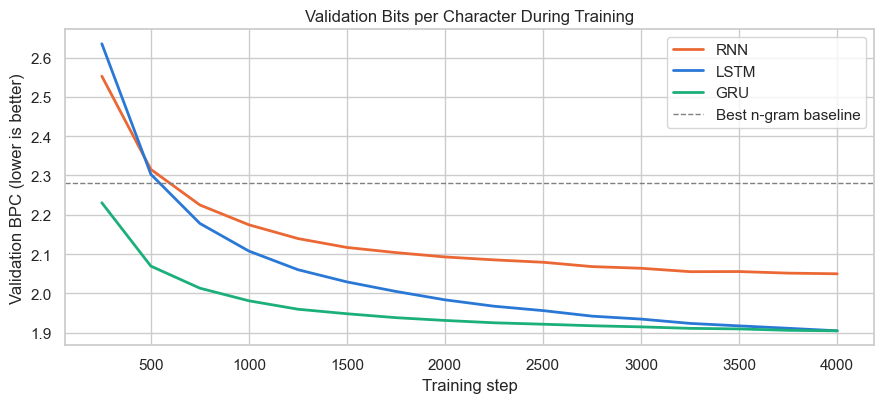

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for cell_type, history in histories.items():
    ax.plot(history["step"], history["val_bpc"], color=MODEL_COLORS[cell_type], linewidth=2, label=cell_type)
best_ngram_val = baseline_table["Validation BPC"].min()
ax.axhline(best_ngram_val, color="gray", linestyle="--", linewidth=1, label="Best n-gram baseline")
ax.set_title("Validation Bits per Character During Training")
ax.set_xlabel("Training step")
ax.set_ylabel("Validation BPC (lower is better)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Model Evaluation

Test BPC is computed over the **entire** test split. The text is cut into consecutive 256-character windows, and the hidden state is carried from one window to the next, so every character is predicted with all of the preceding context.

In [ ]:
@torch.no_grad()
def per_char_losses(model, ids):
    """Negative log2-likelihood of every character after the first, using carried-over state."""
    model.eval()
    usable = (len(ids) - 1) // SEQ_LEN * SEQ_LEN
    x = torch.from_numpy(ids[:usable]).view(1, -1, SEQ_LEN).to(device)
    y = torch.from_numpy(ids[1:usable + 1]).view(1, -1, SEQ_LEN).to(device)
    hidden, losses = None, []
    for i in range(x.shape[1]):
        logits, hidden = model(x[:, i], hidden)
        losses.append(nn.functional.cross_entropy(logits[0], y[0, i], reduction="none"))
    model.train()
    return (torch.cat(losses) / math.log(2)).cpu().numpy()


test_losses = {cell_type: per_char_losses(model, split_ids["test"]) for cell_type, model in models.items()}

results = pd.DataFrame({
    cell_type: {
        "Parameters": sum(p.numel() for p in models[cell_type].parameters()),
        "Training time (min)": train_seconds[cell_type] / 60,
        "Validation BPC": histories[cell_type]["val_bpc"].iloc[-1],
        "Test BPC": test_losses[cell_type].mean(),
    }
    for cell_type in models
}).T
results["Parameters"] = results["Parameters"].astype(int)
pd.concat([
    results.round(3),
    baseline_table.assign(Parameters=np.nan, **{"Training time (min)": np.nan})[results.columns],
])

,Parameters,Training time (min),Validation BPC,Test BPC
RNN,876640.0,1.945,2.050,2.055
LSTM,3340384.0,4.638,1.905,1.902
GRU,2519136.0,3.982,1.905,1.901
"1-gram (add-k, k=0.001)",NaN,NaN,4.612,4.600
"3-gram (add-k, k=0.1)",NaN,NaN,3.071,3.070
"5-gram (add-k, k=0.1)",NaN,NaN,2.281,2.298
"7-gram (add-k, k=0.01)",NaN,NaN,2.441,2.469


### Generated text

Generation feeds the **whole prompt** through the model to build up its hidden state, then samples one character at a time. The temperature controls the trade-off between safe and diverse output: lower values pick likely characters more often. All models use the same prompt and random seed.

In [ ]:
@torch.no_grad()
def generate(model, prompt, length=300, temperature=0.8, seed=RANDOM_SEED):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    x = torch.from_numpy(encode(prompt)).unsqueeze(0).to(device)
    logits, hidden = model(x)
    generated = []
    for _ in range(length):
        probs = torch.softmax(logits[0, -1] / temperature, dim=-1)
        next_id = torch.multinomial(probs, 1, generator=generator)
        generated.append(next_id.item())
        logits, hidden = model(next_id.view(1, 1), hidden)
    model.train()
    return prompt + "".join(id_to_char[generated])


PROMPT = "The government announced on Monday that"
for cell_type, model in models.items():
    print(f"--- {cell_type} (temperature 0.8) ---")
    print(generate(model, PROMPT), "\n")

--- RNN (temperature 0.8) ---
The government announced on Monday that trades and shrew down the family companies since his banking, it is a big type for a second city in a language in whether Sad Trump of AMORIOR FORL' - Get a respect to environment and extanted by National Sea and South Ovalia Roddy Soccer Refinery (R) Michei Petron Raths Street drive for the local  

--- LSTM (temperature 0.8) ---


The government announced on Monday that trade manqus recalls the movement's canidians wrote. The charge can be the father of a United States to approve law enforcement protony Minnesota media at a result of the company perfectly the back that would any of the property of the President Affect its interrupt at state.

Corny Reclients descr 

--- GRU (temperature 0.8) ---
The government announced on Monday that the extreme creation of providing smaller confliction and harassment of the traffic authority even has a problem highly bottom supporters from the time to actively or need to be a streets of his category. She and John Schwarzeneggels is a genical field in time at a father because we have to had the 



To measure generation quality instead of judging it by eye, the next cell generates 20 samples per model and temperature. It then computes the share of generated words that appear in the training vocabulary, counting only words seen at least three times in training. Real but rare words are excluded, so this is a lower bound on spelling quality.

In [ ]:
word_counts = pd.Series(re.findall(r"[a-z]+", split_text["train"].lower())).value_counts()
known_words = set(word_counts[word_counts >= 3].index)


def valid_word_rate(text):
    words = re.findall(r"[a-z]+", text.lower())
    return np.mean([w in known_words for w in words]) if words else np.nan


quality_rows = []
for cell_type, model in models.items():
    for temperature in [0.5, 0.8, 1.0]:
        samples = [generate(model, PROMPT, length=400, temperature=temperature, seed=s)[len(PROMPT):] for s in range(20)]
        quality_rows.append({"Model": cell_type, "Temperature": temperature,
                             "Valid-word rate": np.mean([valid_word_rate(s) for s in samples])})

pd.DataFrame(quality_rows).pivot(index="Model", columns="Temperature", values="Valid-word rate").loc[list(models)].round(3)

Temperature,0.5,0.8,1.0
Model,,,
RNN,0.994,0.939,0.871
LSTM,0.995,0.970,0.907
GRU,0.997,0.967,0.910


## Error Analysis

### 1. Which characters are hard to predict?

Test losses are grouped by the type of the character being predicted. Lowercase letters inside words are usually predictable from spelling. The first character of a new word, capital letters, and digits carry more new information.

In [ ]:
test_targets = split_text["test"][1:1 + len(next(iter(test_losses.values())))]
previous_chars = split_text["test"][:len(test_targets)]


def character_class(current, previous):
    if current == "\n":
        return "Newline"
    if current == " ":
        return "Space"
    if current.isdigit():
        return "Digit"
    if current.isupper():
        return "Uppercase letter"
    if current.isalpha():
        return "Lowercase, word start" if not previous.isalpha() else "Lowercase, inside word"
    return "Punctuation / symbol"


classes = np.array([character_class(c, p) for c, p in zip(test_targets, previous_chars)])
class_table = pd.DataFrame({cell_type: pd.Series(losses).groupby(classes).mean() for cell_type, losses in test_losses.items()})
class_table["Share of test characters"] = pd.Series(classes).value_counts(normalize=True)
class_table.sort_values("LSTM").round(3)

,RNN,LSTM,GRU,Share of test characters
Space,0.574,0.493,0.527,0.163
Newline,1.431,1.266,1.231,0.009
"Lowercase, inside word",1.618,1.478,1.470,0.612
"Lowercase, word start",3.962,3.848,3.828,0.140
Punctuation / symbol,4.951,4.155,4.060,0.032
Digit,4.789,4.578,4.612,0.011
Uppercase letter,5.795,5.518,5.655,0.033


### 2. How much context does each model use?

Each test window is re-scored **from an empty hidden state**, and the average loss is plotted against the position inside the window. A model that keeps using more context should keep improving as the position increases. A model that plateaus early is using only a short history.

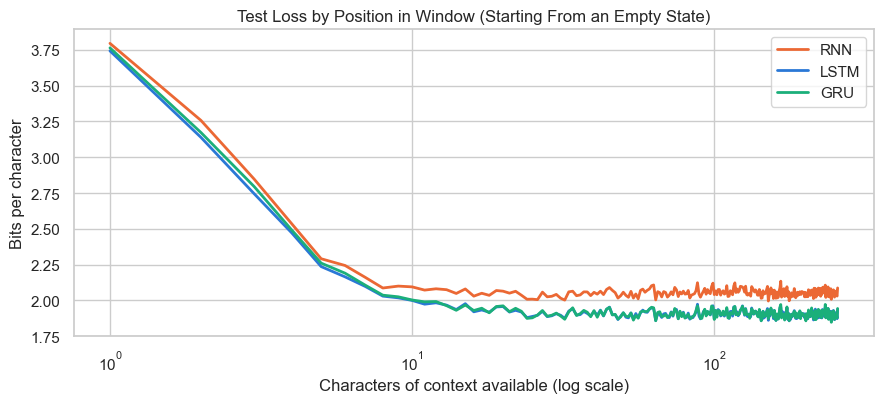

,RNN,LSTM,GRU
Context 1,3.796,3.743,3.764
Context 2-8,2.489,2.412,2.436
Context 9-32,2.047,1.931,1.933
Context 33-128,2.058,1.909,1.909
Context 129-256,2.052,1.900,1.901


In [ ]:
@torch.no_grad()
def loss_by_position(model, ids, n_windows=8_000):
    model.eval()
    starts = np.random.default_rng(1).integers(0, len(ids) - SEQ_LEN - 1, size=n_windows)
    windows = torch.from_numpy(np.stack([ids[s:s + SEQ_LEN + 1] for s in starts])).to(device)
    totals = torch.zeros(SEQ_LEN, device=device)
    for batch in windows.split(256):
        logits, _ = model(batch[:, :-1])
        losses = nn.functional.cross_entropy(logits.transpose(1, 2), batch[:, 1:], reduction="none")
        totals += losses.sum(dim=0)
    model.train()
    return (totals / n_windows / math.log(2)).cpu().numpy()


position_losses = {cell_type: loss_by_position(model, split_ids["test"]) for cell_type, model in models.items()}

fig, ax = plt.subplots(figsize=(9, 4.2))
positions = np.arange(1, SEQ_LEN + 1)
for cell_type, losses in position_losses.items():
    ax.plot(positions, losses, color=MODEL_COLORS[cell_type], linewidth=2, label=cell_type)
ax.set_xscale("log")
ax.set_title("Test Loss by Position in Window (Starting From an Empty State)")
ax.set_xlabel("Characters of context available (log scale)")
ax.set_ylabel("Bits per character")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Average over ranges of positions to smooth out noise
position_ranges = {"1": (1, 1), "2-8": (2, 8), "9-32": (9, 32), "33-128": (33, 128), "129-256": (129, 256)}
pd.DataFrame({cell_type: {f"Context {label}": losses[a - 1:b].mean() for label, (a, b) in position_ranges.items()}
              for cell_type, losses in position_losses.items()}).round(3)

## Key Findings

| Model | Parameters | Training time | Test BPC |
|---|---|---|---|
| Unigram baseline | – | – | 4.600 |
| 5-gram baseline (best n-gram) | – | – | 2.298 |
| RNN | 0.88 M | 1.9 min | 2.055 |
| LSTM | 3.34 M | 4.6 min | 1.902 |
| **GRU** | 2.52 M | 4.0 min | **1.901** |

- **All three recurrent models beat the best n-gram baseline** (2.298 BPC). The 7-gram scores worse than the 5-gram because most 7-character contexts are too sparse to count reliably. Recurrent models avoid this by compressing context into a learned state.
- **Gating is worth about 0.15 BPC.** The LSTM and GRU finish essentially tied (1.902 vs. 1.901), both clearly ahead of the vanilla RNN (2.055). The GRU reaches this with 25% fewer parameters and 14% less training time than the LSTM.
- **The GRU learns fastest.** It is below the n-gram baseline after 250 steps, while the LSTM needs about 750 steps and only catches up with the GRU near the end of the 4,000-step budget. The vanilla RNN plateaus early.
- **The difference is in long-range context.** All three models improve at the same rate over the first few characters, which mainly involves spelling. Beyond about 10 characters of context, the RNN stops improving (around 2.05 BPC), while the gated models keep improving to 1.90. This matches the expected advantage of gates for preserving information over long spans.
- **Hard characters are the ones that start something new.** Uppercase letters (5.5–5.8 bits), digits, punctuation, and the first letter of a word (about 3.8 bits) are expensive. Letters inside a word cost under 1.5 bits for the gated models. The largest gated-model gain is on punctuation (4.95 → 4.06–4.16 bits), which depends on sentence structure.
- **Generation quality follows the BPC ranking.** At temperature 0.8, 97% of the words produced by the LSTM and GRU are real training-vocabulary words, vs. 94% for the RNN. The text is locally fluent but not coherent beyond a phrase, as expected from a small character model trained for a few minutes.

## Limitations

- The comparison uses the same hidden size, not the same parameter count. The LSTM and GRU have about 4× and 3× as many recurrent parameters as the RNN. An equal-parameter comparison would give the RNN a wider hidden layer.
- Each model is trained once with one random seed and a fixed budget of 4,000 steps. Longer training would lower BPC for all three, and repeated runs would quantify run-to-run variance. cuDNN kernels are not fully deterministic, so retraining can shift results in the third decimal place.
- 5,000 documents is a small corpus for language modeling. Larger samples mainly help the gated models, which were still improving when training stopped.

## Next Steps

- Add a small Transformer decoder with the same parameter budget as a modern reference point.
- Train with an equal-parameter design and multiple seeds to report confidence intervals.
- Move from characters to subword tokens (byte-pair encoding) to compare BPC with word-level perplexity.

## Attribution

- Dataset: Gokaslan, A., & Cohen, V. (2019). *OpenWebText Corpus.* Hugging Face dataset `Skylion007/openwebtext`